# Smoothing and Blurring Techniques


Smoothing and blurring are image processing techniques used to reduce noise, remove small details, and create a cleaner image. In OpenCV, these techniques are commonly applied as a preprocessing step before tasks such as edge detection, object recognition, and image segmentation.

Common blurring methods include:

* **Averaging Blur (`cv.blur`)**: Replaces each pixel value with the average of its neighboring pixels.
* **Gaussian Blur (`cv.GaussianBlur`)**: Uses a Gaussian kernel to produce a smoother and more natural blur effect.
* **Median Blur (`cv.medianBlur`)**: Replaces each pixel with the median value of its neighborhood, making it effective for removing salt-and-pepper noise.
* **Bilateral Filter (`cv.bilateralFilter`)**: Reduces noise while preserving important edges in the image.

These techniques help improve image quality and make subsequent computer vision operations more reliable.


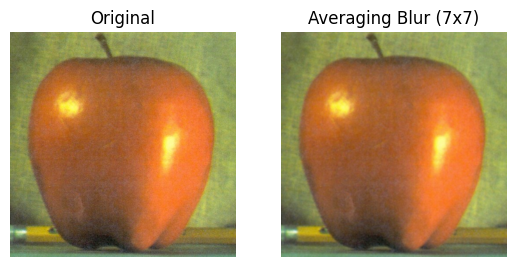

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img=cv.imread("../image/apple.jpg")

# averaging
blurred=cv.blur(img,(3,3))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
plt.title("Averaging Blur (7x7)")
plt.axis("off")

plt.show()

```TEXT
General guidelines
Use small kernels (3×3, 5×5) for slight noise reduction.
Use medium kernels (7×7, 9×9) when the image contains noticeable noise.
Use large kernels (15×15+) only when heavy smoothing is required.

**Gaussian Blur**

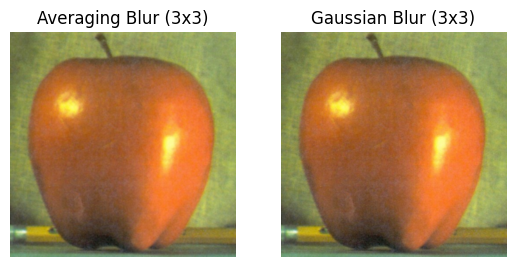

In [23]:
# gaussian blur

gauss=cv.GaussianBlur(img,(3,3),0)

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
plt.title("Averaging Blur (3x3)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(gauss, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blur (3x3)")
plt.axis("off")

plt.show()

```TEXT
Averaging Blur → simple mean of neighbors → more uniform blur
Gaussian Blur → weighted average (center pixel matters more) → more natural smoothing

**Median Blur**

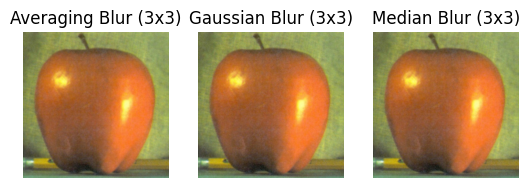

In [24]:
med=cv.medianBlur(img,3)


plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
plt.title("Averaging Blur (3x3)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv.cvtColor(gauss, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blur (3x3)")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(med, cv.COLOR_BGR2RGB))
plt.title("Median Blur (3x3)")
plt.axis("off")


plt.show()


| Kernel | Effect                                  |
| ------ | --------------------------------------- |
| 3      | light noise removal                     |
| 5      | moderate smoothing                      |
| 7      | stronger noise removal                  |
| 9+     | very strong smoothing (may lose detail) |


**Bilateral filter**

```TEXT
Start with:
cv.bilateralFilter(img, 9, 75, 75)

Then adjust:

- Increase d → stronger effect (larger neighborhood)
  • 1–3   → very weak filtering
  • 5–9   → balanced smoothing (recommended range)
  • 11–15 → strong smoothing
  • -1    → auto-calculated by OpenCV

- Increase sigmaColor → more smoothing (less edge preservation)
  • Low: 1–25   → very sharp edges, minimal smoothing
  • Medium: 25–75 → balanced result (recommended range)
  • High: 75–150+ → strong smoothing, edges start fading

- Decrease sigmaColor → sharper edges

- Increase sigmaSpace → more spatial influence (smoother image)
  • 1–25   → local smoothing only
  • 25–75  → moderate smoothing
  • 75–150 → wide-area smoothing

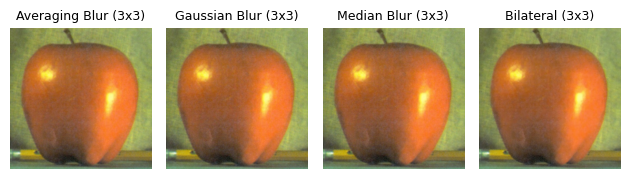

In [44]:
bilateral = cv.bilateralFilter(img, 9, 15, 15)

plt.subplot(1,4,1)
plt.imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
plt.title("Averaging Blur (3x3)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(cv.cvtColor(gauss, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blur (3x3)")
plt.axis("off")


plt.subplot(1,4,3)
plt.imshow(cv.cvtColor(med, cv.COLOR_BGR2RGB))
plt.title("Median Blur (3x3)")
plt.axis("off")


plt.subplot(1,4,4)
plt.imshow(cv.cvtColor(bilateral, cv.COLOR_BGR2RGB))
plt.title("Bilateral (3x3)")
plt.axis("off")

plt.tight_layout()
plt.rcParams['axes.titlesize'] = 9
plt.show()


| Method    | Best For                                                       | Edge Preservation | Speed   |
| --------- | -------------------------------------------------------------- | ----------------- | ------- |
| Averaging | Basic smoothing                                                | Low               | Fast    |
| Gaussian  | General use                                                    | Medium            | Fast    |
| Median    | Salt & pepper noise                                            | High              | Slower  |
| Bilateral | Edge-preserving smoothing (noise reduction + detail retention) | Very High         | Slowest |
